In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library yang diperlukan untuk proses pengolahan citra, ekstraksi fitur, klasifikasi, dan evaluasi model. Library os digunakan untuk mengakses serta mengelola file dan folder dataset, sedangkan OpenCV (cv2) digunakan untuk membaca, mengubah, dan memproses citra digital. NumPy (np) berfungsi untuk mengolah data dalam bentuk array dan melakukan perhitungan numerik secara efisien, sementara Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil pengolahan. Pandas (pd) digunakan untuk menyimpan dan mengelola data hasil ekstraksi fitur dalam bentuk tabel. Library scikit-learn menyediakan berbagai fungsi untuk klasifikasi, evaluasi model, dan pembagian data, sedangkan skimage.feature digunakan untuk menghitung matriks GLCM dan fitur teksturnya. scipy.stats digunakan untuk menghitung nilai entropy, dan seaborn digunakan untuk visualisasi heatmap korelasi antar fitur.

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    sub_folder_files = os.listdir(sub_folder_path)
    for i, filename in enumerate(sub_folder_files):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            continue
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 241
Kelas: ['Corroded', 'Normal']


Kode ini digunakan untuk membaca seluruh citra yang terdapat pada folder dataset dan mempersiapkannya untuk proses pengolahan selanjutnya. Program terlebih dahulu membuat tiga list, yaitu data untuk menyimpan citra mentah, labels untuk menyimpan kelas citra berdasarkan nama subfolder, dan file_name untuk menyimpan nama file gambar. Selanjutnya program melakukan perulangan pada setiap subfolder di dalam folder dataset, yaitu corroded dan normal. Setiap subfolder dianggap sebagai sebuah kelas data. Setiap gambar dibaca menggunakan cv.imread(), kemudian dilakukan pengecekan untuk memastikan gambar berhasil dimuat. Pada tahap ini citra belum diproses, melainkan disimpan dalam bentuk aslinya agar preprocessing dapat dilakukan secara terpisah dan terstruktur.

# Data Preparation

### Define Preprocessing Function

In [3]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def histogram_equalization_grayscale(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    equalized_result = cv.equalizeHist(img)

    return equalized_result

In [4]:
def prepro(image):
    # Resize + Grayscale
    img = resize_grayscale(image)
    # histogram_equalization_grayscale
    img = histogram_equalization_grayscale(img)
    return img

Kode ini berisi beberapa fungsi yang digunakan pada tahap preprocessing citra. Fungsi resize_grayscale() digunakan untuk mengubah ukuran gambar menjadi 128×128 piksel agar seluruh citra memiliki dimensi yang seragam, kemudian mengonversi citra ke grayscale (jika citra input masih memiliki 3 channel warna) sehingga setiap piksel hanya memiliki satu nilai intensitas dengan tipe data uint8.

Fungsi histogram_equalization_grayscale() digunakan untuk meningkatkan kontras citra yang sudah berformat grayscale. Fungsi ini bekerja dengan meratakan distribusi akumulatif dari histogram intensitas piksel (menggunakan fungsi cv.equalizeHist()). Proses ini membuat detail-detail tekstur permukaan pipa yang awalnya samar atau terlalu gelap/terang menjadi lebih tegas, seimbang, dan lebih mudah dikenali oleh algoritma ekstraksi fitur.

Fungsi prepro() merupakan fungsi utama yang mengintegrasikan seluruh tahapan preprocessing secara berurutan, dimulai dari penyeragaman ukuran dan konversi warna (Resize & Grayscale), hingga peningkatan kualitas detail kontras (Histogram Equalization).

## Percobaan 2 (Resize + Grayscale + Histogram Equalization)

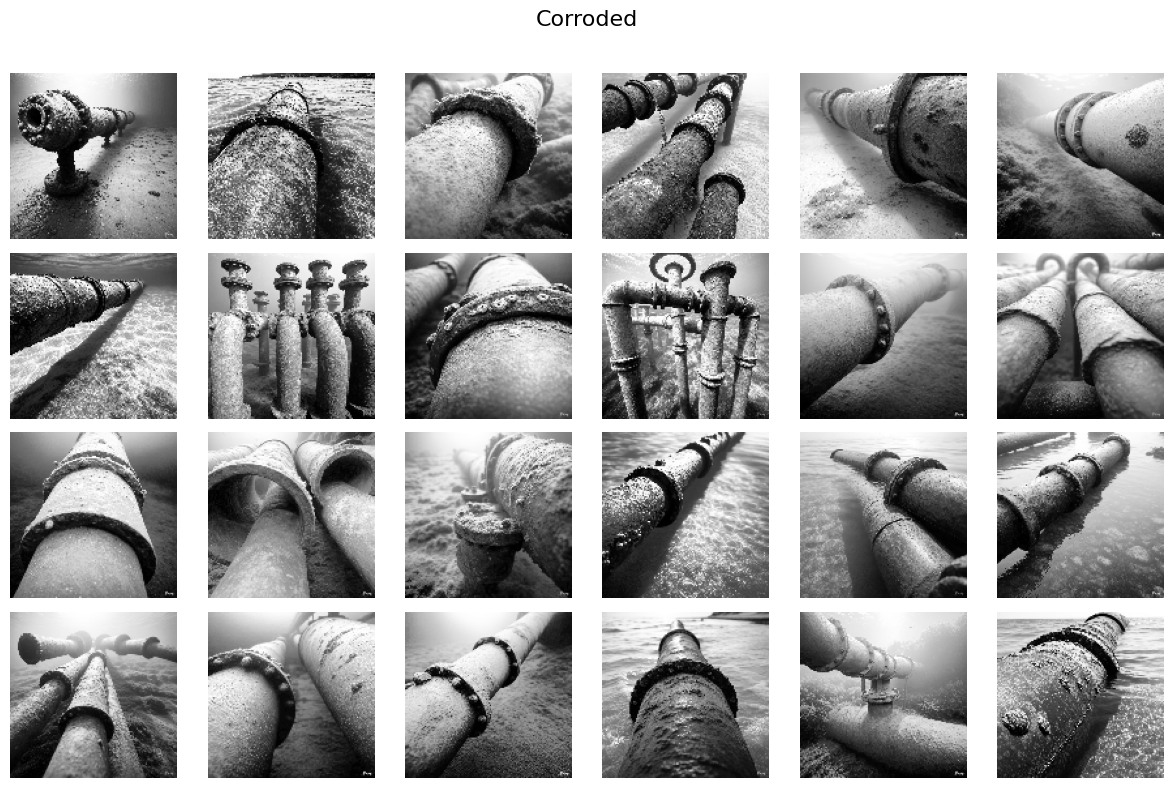

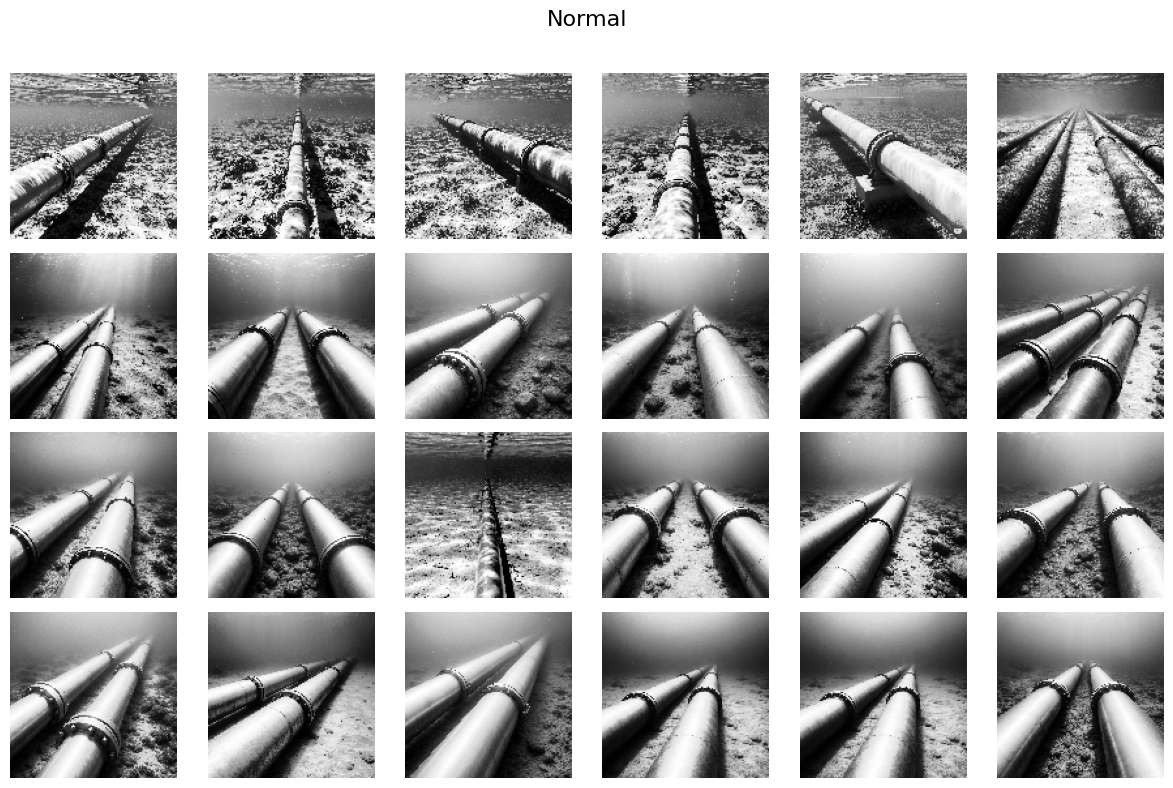

In [5]:
def percobaan2(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

Kode ini digunakan untuk menerapkan pipeline preprocessing Percobaan 2 ke seluruh citra dalam dataset. Fungsi percobaan2() memanggil fungsi prepro() yang telah didefinisikan sebelumnya, sehingga setiap citra melewati tahap Resize, Grayscale, dan Histogram Equalization secara berurutan. Hasilnya disimpan dalam list dataPreprocessed.

Selanjutnya, program menampilkan visualisasi hasil preprocessing untuk masing-masing kelas (corroded dan normal) dalam bentuk grid 4×6 (maksimal 24 citra per kelas). Visualisasi ini berguna untuk memastikan secara visual bahwa proses resize, grayscale, dan histogram equalization telah berhasil diterapkan dengan benar pada seluruh citra sebelum lanjut ke tahap ekstraksi fitur.

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode ini digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM) dari sebuah citra grayscale. Fungsi glcm() menerima dua parameter, yaitu citra dan sudut (derajat) yang akan digunakan untuk menghitung hubungan antar piksel tetangga. Sudut yang digunakan adalah 0°, 45°, 90°, dan 135°, yang masing-masing dikonversi ke dalam radian. Matriks GLCM dihitung menggunakan fungsi graycomatrix() dari skimage.feature dengan jarak antar piksel sejauh 1, 256 level intensitas, serta sifat matriks yang simetris dan dinormalisasi. Matriks inilah yang nantinya menjadi dasar perhitungan berbagai fitur tekstur pada tahap selanjutnya.

In [7]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode ini digunakan untuk menghitung berbagai fitur tekstur dari matriks Gray Level Co-occurrence Matrix (GLCM) yang telah dibentuk sebelumnya. Fungsi correlation_feat() menghitung tingkat hubungan linear antar piksel tetangga, dissimilarity() mengukur tingkat perbedaan intensitas antar piksel, dan homogenity() mengukur tingkat keseragaman tekstur citra. Fungsi contrast() menghitung variasi intensitas lokal yang mencerminkan tingkat kekasaran tekstur, sedangkan ASM() (Angular Second Moment) dan energy() mengukur tingkat keteraturan distribusi piksel pada citra. Fungsi entropyGlcm() menghitung tingkat ketidakteraturan atau kompleksitas tekstur citra menggunakan entropy dari seluruh nilai pada matriks GLCM. Ketujuh fitur ini bersama-sama membentuk representasi numerik dari karakteristik tekstur permukaan pipa, baik yang berkarat maupun yang normal.

In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 241 citra.


Kode ini digunakan untuk melakukan ekstraksi fitur tekstur GLCM pada seluruh citra hasil preprocessing. Tahap pertama adalah menghitung matriks GLCM untuk setiap citra pada keempat sudut (0°, 45°, 90°, 135°) menggunakan fungsi glcm(), kemudian hasilnya disimpan dalam empat list (Derajat0, Derajat45, Derajat90, Derajat135).

Tahap selanjutnya adalah menghitung tujuh fitur tekstur (contrast, dissimilarity, homogeneity, entropy, ASM, energy, dan correlation) untuk setiap citra pada keempat sudut tersebut menggunakan fungsi-fungsi yang telah didefinisikan sebelumnya. Setiap nilai fitur disimpan ke dalam list-list terpisah sesuai nama fitur dan sudutnya (misalnya Kontras0 untuk fitur contrast pada sudut 0°). Pada akhir proses, dicetak jumlah citra yang telah berhasil diekstraksi fiturnya sebagai konfirmasi bahwa proses ekstraksi telah selesai dilakukan untuk seluruh data.

## Ekstraksi ke CSV

In [9]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)

#save to csv
os.makedirs('./hasil_ekstraksi', exist_ok=True)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi_P2.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi_P2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,001.jpg,Corroded,1090.818221,1383.722735,1238.259781,1476.431025,0.150614,0.123713,0.179942,0.140111,...,0.000345,0.000293,0.018229,0.016644,0.018574,0.017108,0.899980,0.873004,0.885797,0.864499
1,002.jpg,Corroded,2798.375800,3726.981462,3658.478839,3891.903776,0.070473,0.057576,0.059687,0.054548,...,0.000156,0.000151,0.013563,0.012396,0.012508,0.012277,0.743242,0.656740,0.662505,0.641513
2,003.jpg,Corroded,567.339505,825.900676,747.800935,870.876620,0.128090,0.098055,0.107393,0.091619,...,0.000165,0.000144,0.013668,0.012351,0.012838,0.012004,0.947714,0.923840,0.930927,0.919693
3,004.jpg,Corroded,1669.464628,2161.092876,1782.158834,1964.388555,0.102656,0.077985,0.096787,0.095154,...,0.000211,0.000205,0.015373,0.013881,0.014515,0.014318,0.846695,0.801174,0.836311,0.819280
4,005.jpg,Corroded,458.370694,658.654659,566.485667,608.929072,0.156882,0.152200,0.151874,0.118531,...,0.000652,0.000546,0.025684,0.024931,0.025544,0.023366,0.956740,0.937756,0.946673,0.942462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,116.png,Normal,1056.934240,1482.571827,1480.853469,1604.001860,0.213194,0.178929,0.224275,0.216239,...,0.000667,0.000636,0.025948,0.023779,0.025818,0.025217,0.902300,0.863281,0.863654,0.852080
237,117.png,Normal,729.907849,1350.709219,1116.571112,1072.766756,0.179564,0.114933,0.164088,0.195934,...,0.000671,0.000743,0.027145,0.022710,0.025907,0.027266,0.932528,0.875195,0.896583,0.900879
238,118.png,Normal,493.609744,931.770538,738.510888,789.422221,0.260556,0.191688,0.241172,0.239427,...,0.001073,0.000998,0.033968,0.029771,0.032763,0.031592,0.954423,0.914176,0.932021,0.927292
239,119.png,Normal,449.066068,842.554529,659.328002,605.607911,0.231045,0.170223,0.188972,0.197746,...,0.000445,0.000473,0.023379,0.019678,0.021099,0.021757,0.958418,0.922077,0.939130,0.943990


Kode ini digunakan untuk menggabungkan seluruh hasil ekstraksi fitur GLCM (28 fitur: 7 fitur × 4 sudut) beserta nama file dan label kelasnya ke dalam satu DataFrame bernama dataTable. DataFrame ini kemudian disimpan ke dalam file CSV pada folder hasil_ekstraksi dengan nama hasil_ekstraksi_P2.csv, agar data hasil ekstraksi dapat digunakan kembali tanpa perlu mengulang seluruh proses ekstraksi dari awal. File CSV tersebut selanjutnya dibaca kembali ke dalam variabel hasilEkstrak sebagai tabel fitur final yang akan digunakan pada tahap seleksi fitur dan pemodelan.

## Feature Selection

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 8
Fitur terpilih        : ['Contrast0', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Dissimilarity0', 'Entropy0', 'ASM0']


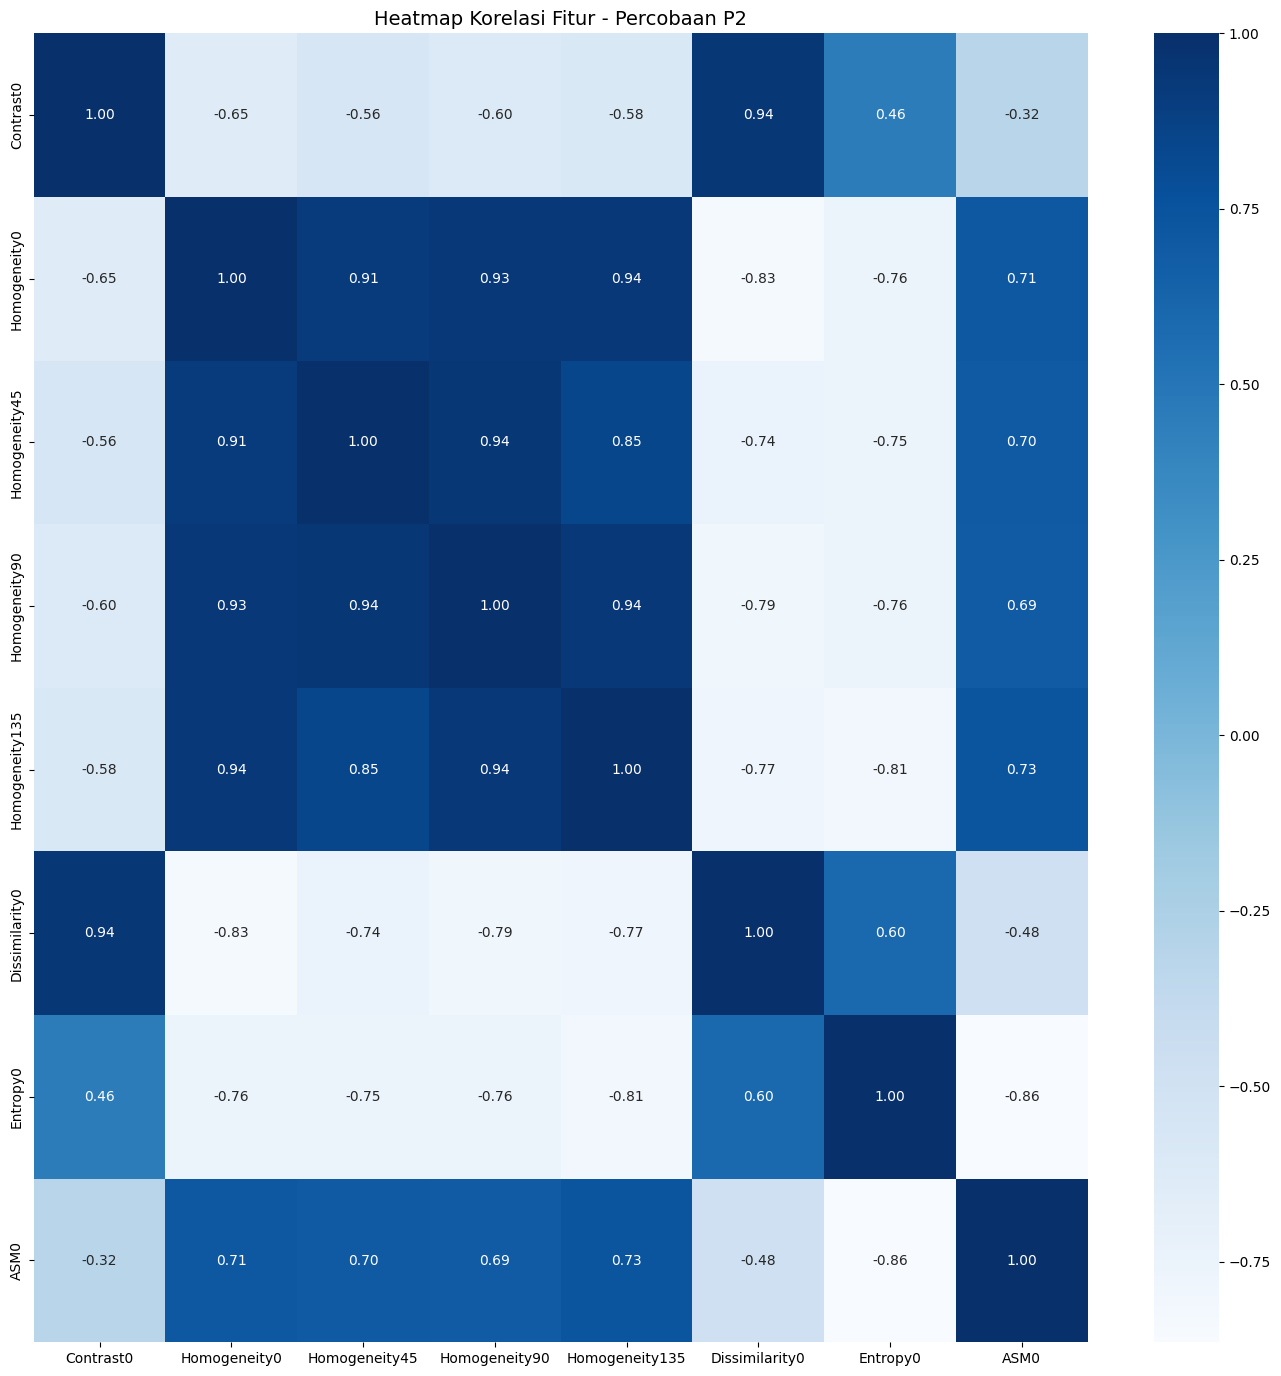

In [ ]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan P2', fontsize=14)
plt.show()

Kode ini digunakan untuk melakukan seleksi fitur guna mengurangi redundansi antar fitur hasil ekstraksi GLCM. Tahap pertama adalah menghitung matriks korelasi antar 28 fitur menggunakan corr_matrix. Selanjutnya, dilakukan pengecekan pasangan fitur yang memiliki nilai korelasi absolut lebih besar atau sama dengan 0.95 (threshold = 0.95). Jika ditemukan dua fitur dengan korelasi yang sangat tinggi, salah satu fitur akan dihapus karena dianggap membawa informasi yang hampir sama dengan fitur lainnya, sehingga dapat mengurangi redundansi data dan kompleksitas model.

Fitur-fitur yang lolos seleksi disimpan ke dalam variabel x_new sebagai variabel independen (input model), sedangkan label kelas disimpan pada variabel y. Pada akhir proses, dicetak jumlah fitur sebelum dan sesudah seleksi beserta daftar nama fitur yang terpilih. Sebagai visualisasi tambahan, ditampilkan heatmap korelasi antar fitur terpilih untuk memverifikasi secara visual bahwa fitur-fitur dengan korelasi tinggi sudah tidak ada lagi.

## Splitting Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(192, 8)
(49, 8)


Kode ini digunakan untuk membagi data menjadi data latih (training set) dan data uji (testing set) dengan proporsi 80:20 menggunakan fungsi train_test_split(). Parameter test_size=0.2 berarti 20% data dialokasikan untuk pengujian, sedangkan random_state=42 digunakan agar hasil pembagian data bersifat konsisten dan dapat direproduksi setiap kali notebook dijalankan ulang. Shape dari X_train dan X_test dicetak untuk memastikan jumlah data pada masing-masing set sudah sesuai dengan proporsi yang diinginkan.

## Normalisasi Fitur

In [ ]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

Kode ini digunakan untuk melakukan normalisasi fitur menggunakan metode Z-score (standardisasi). Rata-rata (mean_train) dan standar deviasi (std_train) dihitung hanya dari data training, kemudian digunakan untuk menormalisasi baik data training maupun data testing. Pendekatan ini penting agar tidak terjadi data leakage, yaitu kebocoran informasi dari data uji ke dalam proses normalisasi. Setelah normalisasi, seluruh fitur akan memiliki skala yang sebanding (mean mendekati 0 dan standar deviasi mendekati 1), sehingga model seperti KNN dan SVM yang sensitif terhadap perbedaan skala antar fitur dapat bekerja secara optimal.

# MODELING

## Define Model

In [ ]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Kode ini digunakan untuk mendefinisikan fungsi evaluasi serta tiga model klasifikasi yang akan dibandingkan performanya. Fungsi generateClassificationReport() digunakan untuk mencetak hasil evaluasi model secara lengkap, meliputi classification report (precision, recall, f1-score per kelas), confusion matrix, dan nilai accuracy.

Selanjutnya didefinisikan tiga model klasifikasi, yaitu rf (Random Forest) dengan 100 pohon keputusan (n_estimators=100), svm (Support Vector Machine) dengan kernel RBF (Radial Basis Function), dan knn (K-Nearest Neighbors) dengan jumlah tetangga sebanyak 5 (n_neighbors=5). Parameter random_state=42 digunakan agar hasil pelatihan model bersifat konsisten setiap kali dijalankan ulang.

## Hasil Modeling Random Forest

In [ ]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Corroded       1.00      1.00      1.00        95
      Normal       1.00      1.00      1.00        97

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192

[[95  0]
 [ 0 97]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.88      0.85      0.86        26
      Normal       0.83      0.87      0.85        23

    accuracy                           0.86        49
   macro avg       0.86      0.86      0.86        49
weighted avg       0.86      0.86      0.86        49

[[22  4]
 [ 3 20]]
Accuracy: 0.8571428571428571


Kode ini digunakan untuk melatih model Random Forest menggunakan data training (rf.fit()), kemudian melakukan prediksi dan evaluasi pada data training maupun data testing menggunakan fungsi generateClassificationReport(). Evaluasi pada data training menunjukkan seberapa baik model mempelajari pola dari data yang dilatih, sedangkan evaluasi pada data testing menunjukkan kemampuan generalisasi model terhadap data baru yang belum pernah dilihat sebelumnya. Jika akurasi pada data training jauh lebih tinggi dibandingkan data testing, hal ini dapat menjadi indikasi terjadinya overfitting pada model.

## Hasil Modeling SVM

In [ ]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.96      0.92      0.94        95
      Normal       0.92      0.96      0.94        97

    accuracy                           0.94       192
   macro avg       0.94      0.94      0.94       192
weighted avg       0.94      0.94      0.94       192

[[87  8]
 [ 4 93]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.88      0.85      0.86        26
      Normal       0.83      0.87      0.85        23

    accuracy                           0.86        49
   macro avg       0.86      0.86      0.86        49
weighted avg       0.86      0.86      0.86        49

[[22  4]
 [ 3 20]]
Accuracy: 0.8571428571428571


Kode ini digunakan untuk melatih model Support Vector Machine (SVM) dengan kernel RBF menggunakan data training (svm.fit()), kemudian melakukan prediksi dan evaluasi pada data training maupun data testing dengan cara yang sama seperti pada model Random Forest. SVM bekerja dengan mencari hyperplane terbaik yang mampu memisahkan kelas corroded dan normal berdasarkan fitur GLCM yang telah dinormalisasi pada tahap sebelumnya.

## Hasil Modeling KNN

In [ ]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.95      0.91      0.92        95
      Normal       0.91      0.95      0.93        97

    accuracy                           0.93       192
   macro avg       0.93      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192

[[86  9]
 [ 5 92]]
Accuracy: 0.9270833333333334

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.88      0.85      0.86        26
      Normal       0.83      0.87      0.85        23

    accuracy                           0.86        49
   macro avg       0.86      0.86      0.86        49
weighted avg       0.86      0.86      0.86        49

[[22  4]
 [ 3 20]]
Accuracy: 0.8571428571428571


Kode ini digunakan untuk melatih model K-Nearest Neighbors (KNN) dengan k=5 menggunakan data training (knn.fit()), kemudian melakukan prediksi dan evaluasi pada data training maupun data testing. KNN mengklasifikasikan setiap data uji berdasarkan kelas mayoritas dari 5 tetangga terdekatnya pada ruang fitur GLCM yang telah dinormalisasi.

## Evaluasi Confusion Matrix

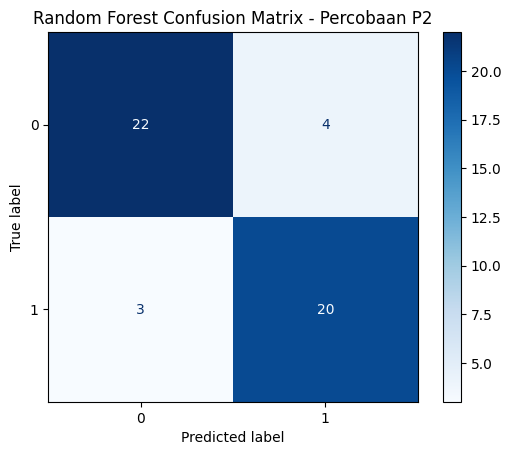

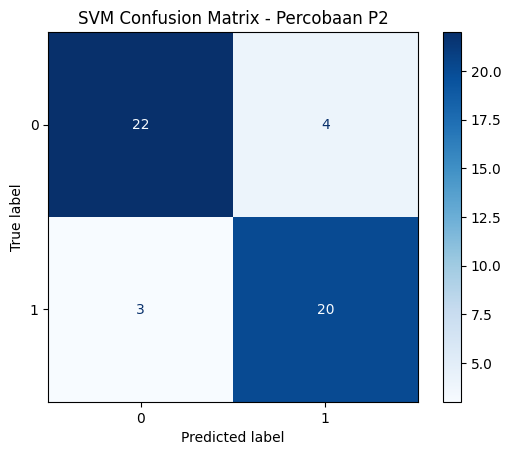

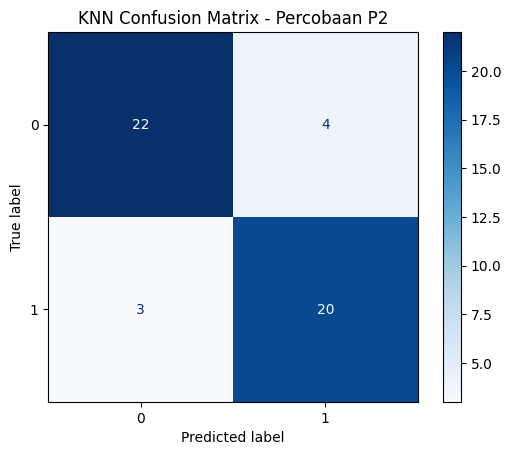

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan P2")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan P2")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan P2")

Kode ini digunakan untuk memvisualisasikan confusion matrix dari ketiga model (Random Forest, SVM, dan KNN) dalam bentuk heatmap menggunakan fungsi plot_confusion_matrix(). Confusion matrix ini memperlihatkan secara visual jumlah prediksi benar dan salah untuk masing-masing kelas (corroded dan normal) pada data testing, sehingga memudahkan perbandingan performa ketiga model secara langsung dan dapat digunakan untuk mengidentifikasi kelas mana yang paling sering salah diklasifikasikan oleh masing-masing model.

In [ ]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)

#save to csv
os.makedirs('./hasil_klasifikasi', exist_ok=True)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi_P2.csv', index=False)
print("File hasil_klasifikasi_P2.csv berhasil disimpan!")
df_hasil

File hasil_klasifikasi_P2.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,1.000000,0.857143,0.858095,0.857143,0.857262
1,SVM,0.937500,0.857143,0.858095,0.857143,0.857262
2,KNN,0.927083,0.857143,0.858095,0.857143,0.857262


Kode ini digunakan untuk merangkum dan menyimpan hasil perbandingan performa ketiga model ke dalam satu tabel. Untuk setiap model (Random Forest, SVM, dan KNN), dihitung nilai Accuracy_Train (akurasi pada data training), Accuracy_Test (akurasi pada data testing), Precision, Recall, dan F1_Score (ketiganya dihitung dengan average='weighted' agar mempertimbangkan proporsi masing-masing kelas). Hasil rangkuman ini disimpan ke dalam DataFrame df_hasil, kemudian diekspor ke dalam file hasil_klasifikasi_P2.csv pada folder hasil_klasifikasi. Tabel inilah yang menjadi acuan utama untuk membandingkan dan menentukan model mana yang memberikan performa terbaik dalam mengklasifikasikan kondisi korosi pipa pada Percobaan P2.